
# Comparación de modelos y estrategias de prompting

Este notebook fusiona:

- **4 archivos JSON** de evaluación (`results`) — uno por estrategia de prompting
- **4 archivos CSV** de sintaxis (`avg_pqs_modified`, `total_passed`, etc.) — uno por estrategia de prompting

y genera exactamente las visualizaciones acordadas para presentación:

1. **Matriz de calidad**  
   - BERTScore F1  
   - ROUGE-L

2. **Matriz de tiempo**  
   - `avg_time_per_sample`

3. **Matriz de sintaxis**  
   - `avg_pqs_modified`  
   - con `n = total_modified_files` dentro de cada celda

4. **Gráfico de respaldo de sintaxis**  
   - barras apiladas al 100% para los **4 finalistas**
   - solo se consideran: **Qwen, Llama, Gemma y Zephyr**
   - para cada uno se elige automáticamente su mejor estrategia de prompting usando:
     1. mayor `avg_pqs_modified`
     2. mayor `bertscore_f1`
     3. menor `avg_time_per_sample`

> El notebook usa `matplotlib` y `pandas`. No depende de `seaborn`.



## Estructura esperada de archivos

Edita únicamente la celda de **configuración** para apuntar a tus nombres reales de archivo.

Ejemplo de estructura en una misma carpeta:

```text
data/
├─ eval_simple.json
├─ eval_steps.json
├─ eval_fewshot.json
├─ eval_steps_fewshot.json
├─ syntax_simple.csv
├─ syntax_steps.csv
├─ syntax_fewshot.csv
├─ syntax_steps_fewshot.csv
```

Cada JSON debe tener un formato como este:

```json
{
  "timestamp": "...",
  "dataset": "...",
  "total_samples": 100,
  "models_evaluated": [...],
  "results": [
    {
      "model_name": "Qwen2.5-7B-Instruct",
      "avg_time_per_sample": 12.34,
      "rougeL": 0.85,
      "bertscore_f1": 0.97
    }
  ]
}
```

Cada CSV de sintaxis debe contener al menos estas columnas:

- `model_name`
- `avg_pqs_modified`
- `total_modified_files`
- `total_passed`
- `total_partially_parsed`
- `total_failed`
- `total_unknown`

El notebook también acepta alias comunes como `avg_psq_modified` y los renombra automáticamente.


In [66]:

# =========================
# 1) Imports
# =========================
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [67]:

# =========================
# 2) Configuración (EDITAR)
# =========================

BASE_DIR = Path(".") 
DATA_DIR = Path(".") 

PROMPT_CONFIG = {
    "simple": {
        "label": "Simple",
        "json": BASE_DIR / "generation_results_20260402_204218.json",
        "csv":  BASE_DIR / "config" / "simple_batfish_verified_summary.csv",
    },
    "steps": {
        "label": "Steps",
        "json": BASE_DIR / "generation_results_20260405_050123.json",
        "csv":  BASE_DIR / "pasos" / "predictions2_batfish_verified_summary.csv",
    },
    "fewshot": {
        "label": "Few-shot",
        "json": BASE_DIR / "confew.json",
        "csv":  BASE_DIR / "confew" / "confew_batfish_verified_summary.csv",
    },
    "steps_fewshot": {
        "label": "Steps + Few-shot",
        "json": BASE_DIR / "contodochainyfew.json",
        "csv":  BASE_DIR / "chain-few" / "chain-few_batfish_verified_summary.csv",
    },
}

# Orden fijo de estrategias en todas las matrices
PROMPT_ORDER = ["simple", "steps", "fewshot", "steps_fewshot"]

# Modelos a usar en el gráfico de respaldo de sintaxis
FINALIST_MODELS = [
    "Qwen2.5-7B-Instruct",
    "Llama-3.1-8B-Instruct",
    "Gemma-2-9B-it",
    "Zephyr-7B",
]

# Alias cortos para que las figuras queden más limpias
MODEL_LABELS = {
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B",
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B",
    "Gemma-2-9B-it": "Gemma-2-9B",
    "Zephyr-7B": "Zephyr-7B",
    "FLAN-T5-large": "FLAN-T5-large",
    "FLAN-T5-base": "FLAN-T5-base",
}

# Exportación opcional de figuras
EXPORT_FIGURES = False
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True) 


In [68]:

# =========================
# 3) Funciones auxiliares
# =========================

REQUIRED_JSON_COLUMNS = [
    "model_name",
    "samples_evaluated",
    "total_time_s",
    "avg_time_per_sample",
    "rouge1",
    "rouge2",
    "rougeL",
    "rouge1_std",
    "rouge2_std",
    "rougeL_std",
    "bertscore_p",
    "bertscore_r",
    "bertscore_f1",
    "bertscore_f1_std",
]

REQUIRED_CSV_COLUMNS = [
    "model_name",
    "avg_pqs_modified",
    "total_modified_files",
    "total_passed",
    "total_partially_parsed",
    "total_failed",
    "total_unknown",
]

CSV_ALIASES = {
    "avg_psq_modified": "avg_pqs_modified",
    "avg_psq": "avg_pqs_modified",
}

def _read_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el JSON: {path}")
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError as e:
        raise ValueError(
            f"JSON inválido o incompleto en '{path}'. "
            f"Línea {e.lineno}, columna {e.colno}: {e.msg}"
        ) from e

def load_eval_json(path: Path, prompt_type: str) -> pd.DataFrame:
    data = _read_json(path)
    if "results" not in data or not isinstance(data["results"], list):
        raise ValueError(f"El JSON '{path}' no contiene una lista válida en 'results'.")

    rows = []
    for item in data["results"]:
        row = {col: item.get(col, np.nan) for col in REQUIRED_JSON_COLUMNS}
        row["prompt_type"] = prompt_type
        row["prompt_label"] = PROMPT_CONFIG[prompt_type]["label"]
        row["timestamp"] = data.get("timestamp", None)
        row["dataset"] = data.get("dataset", None)
        row["total_samples"] = data.get("total_samples", None)
        rows.append(row)

    df = pd.DataFrame(rows)
    missing = [c for c in REQUIRED_JSON_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el JSON '{path}': {missing}")
    return df

def load_syntax_csv(path: Path, prompt_type: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el CSV: {path}")

    df = pd.read_csv(path)
    df = df.rename(columns=CSV_ALIASES)
    df["prompt_type"] = prompt_type
    df["prompt_label"] = PROMPT_CONFIG[prompt_type]["label"]

    missing = [c for c in REQUIRED_CSV_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el CSV '{path}': {missing}")

    return df

def build_master_dataframe(prompt_config: dict) -> pd.DataFrame:
    eval_frames = []
    syntax_frames = []

    for prompt_type, cfg in prompt_config.items():
        eval_frames.append(load_eval_json(Path(cfg["json"]), prompt_type))
        syntax_frames.append(load_syntax_csv(Path(cfg["csv"]), prompt_type))

    eval_df = pd.concat(eval_frames, ignore_index=True)
    syntax_df = pd.concat(syntax_frames, ignore_index=True)

    merged = eval_df.merge(
        syntax_df,
        on=["model_name", "prompt_type", "prompt_label"],
        how="inner",
        validate="one_to_one",
    )

    numeric_cols = [
        "samples_evaluated", "total_time_s", "avg_time_per_sample",
        "rouge1", "rouge2", "rougeL", "rouge1_std", "rouge2_std", "rougeL_std",
        "bertscore_p", "bertscore_r", "bertscore_f1", "bertscore_f1_std",
        "avg_pqs_modified", "total_modified_files",
        "total_passed", "total_partially_parsed", "total_failed", "total_unknown",
    ]
    for col in numeric_cols:
        if col in merged.columns:
            merged[col] = pd.to_numeric(merged[col], errors="coerce")

    merged["model_label"] = merged["model_name"].map(MODEL_LABELS).fillna(merged["model_name"])
    merged["prompt_type"] = pd.Categorical(merged["prompt_type"], categories=PROMPT_ORDER, ordered=True)
    merged["prompt_label"] = pd.Categorical(
        merged["prompt_label"],
        categories=[PROMPT_CONFIG[p]["label"] for p in PROMPT_ORDER],
        ordered=True,
    )
    return merged

def choose_model_order(df: pd.DataFrame) -> list[str]:
    summary = (
        df.groupby(["model_name", "model_label"], as_index=False)
          .agg(
              mean_pqs=("avg_pqs_modified", "mean"),
              mean_f1=("bertscore_f1", "mean"),
          )
          .sort_values(["mean_pqs", "mean_f1"], ascending=[False, False])
    )
    return summary["model_name"].tolist()

def make_matrix(df: pd.DataFrame, value_col: str, model_order: list[str], prompt_order: list[str]) -> pd.DataFrame:
    matrix = (
        df.pivot(index="model_name", columns="prompt_type", values=value_col)
          .reindex(index=model_order, columns=prompt_order)
    )
    matrix.index = [MODEL_LABELS.get(m, m) for m in matrix.index]
    matrix.columns = [PROMPT_CONFIG[p]["label"] for p in matrix.columns]
    return matrix

def make_annotation_matrix(
    value_matrix: pd.DataFrame,
    extra_matrix: pd.DataFrame = None,
    value_fmt: str = "{:.3f}",
    extra_prefix: str = "n=",
):
    ann = np.empty(value_matrix.shape, dtype=object)
    for i in range(value_matrix.shape[0]):
        for j in range(value_matrix.shape[1]):
            value = value_matrix.iat[i, j]
            if pd.isna(value):
                ann[i, j] = "—"
                continue
            text = value_fmt.format(value)
            if extra_matrix is not None:
                extra = extra_matrix.iat[i, j]
                if pd.notna(extra):
                    text += f"\n{extra_prefix}{int(extra)}"
            ann[i, j] = text
    return ann

def _best_text_color(norm_value: float) -> str:
    return "black" if norm_value < 0.55 else "white"

def plot_heatmap(
    matrix: pd.DataFrame,
    title: str,
    cmap: str = "YlGn",
    annotate: np.ndarray = None,
    fmt: str = "{:.3f}",
    higher_is_better: bool = True,
    figsize: tuple = (8, 4.8),
    cbar_label: str = None,
):
    data = matrix.values.astype(float)
    if not higher_is_better:
        cmap = cmap + "_r" if not cmap.endswith("_r") else cmap

    finite_values = data[np.isfinite(data)]
    vmin = finite_values.min() if finite_values.size else 0.0
    vmax = finite_values.max() if finite_values.size else 1.0
    if math.isclose(vmin, vmax):
        vmin = vmin - 1e-9
        vmax = vmax + 1e-9

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=0)
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_yticklabels(matrix.index)

    ax.set_title(title, pad=12)
    ax.set_xlabel("Prompting strategy")
    ax.set_ylabel("Model")

    ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    norm = Normalize(vmin=vmin, vmax=vmax)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center", color="black", fontsize=9)
                continue
            text = annotate[i, j] if annotate is not None else fmt.format(val)
            text_color = _best_text_color(norm(val))
            ax.text(j, i, text, ha="center", va="center", color=text_color, fontsize=9, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label:
        cbar.set_label(cbar_label)

    fig.tight_layout()
    return fig, ax

def maybe_save(fig, filename: str):
    if EXPORT_FIGURES:
        out = FIG_DIR / filename
        fig.savefig(out, bbox_inches="tight")
        print(f"Figura exportada: {out}")

In [69]:

# =========================
# 4) Cargar y fusionar datos
# =========================
master_df = build_master_dataframe(PROMPT_CONFIG)

expected_rows = len(PROMPT_CONFIG) * master_df["model_name"].nunique()
if len(master_df) != expected_rows:
    warnings.warn(
        f"Se esperaban {expected_rows} filas combinadas y se obtuvieron {len(master_df)}. "
        "Revisa si falta algún modelo en algún JSON/CSV."
    )

model_order = choose_model_order(master_df)

display(master_df.sort_values(["model_name", "prompt_type"]).reset_index(drop=True))
print(f"Filas totales: {len(master_df)}")
print(f"Modelos detectados: {master_df['model_name'].nunique()}")


,model_name,samples_evaluated,total_time_s,avg_time_per_sample,rouge1,rouge2,rougeL,rouge1_std,rouge2_std,rougeL_std,bertscore_p,bertscore_r,bertscore_f1,bertscore_f1_std,prompt_type,prompt_label,timestamp,dataset,total_samples,rows,avg_pqs_modified,median_pqs_modified,total_modified_files,total_passed,total_partially_parsed,total_failed,total_unknown,model_label
0,FLAN-T5-base,100,798.67,7.9867,0.0030,0.0006,0.0027,0.0215,0.0053,0.0183,0.8484,0.7992,0.8229,0.0170,simple,Simple,20260402_204218,D:\tesis\Agent\dataset_v2.csv,100,100,0.000000,0.0,0,0,0,0,0,FLAN-T5-base
1,FLAN-T5-base,100,345.86,3.4586,0.0419,0.0039,0.0347,0.0620,0.0214,0.0532,0.8237,0.8050,0.8137,0.0231,steps,Steps,20260405_050123,D:\tesis\Agent\dataset_v2.csv,100,100,0.000000,0.0,0,0,0,0,0,FLAN-T5-base
2,FLAN-T5-base,100,229.28,2.2928,0.1046,0.0252,0.0881,0.1172,0.0447,0.0996,0.8402,0.8268,0.8330,0.0359,fewshot,Few-shot,20260406_230914,D:\tesis\Agent\dataset_v2.csv,100,100,0.000000,0.0,0,0,0,0,0,FLAN-T5-base
3,FLAN-T5-base,100,79.09,0.7909,0.0767,0.0221,0.0730,0.1007,0.0543,0.0968,0.8862,0.8399,0.8620,0.0196,steps_fewshot,Steps + Few-shot,20260406_171212,D:\tesis\Agent\dataset_v2.csv,100,100,0.000000,0.0,0,0,0,0,0,FLAN-T5-base
4,FLAN-T5-large,100,1305.84,13.0584,0.0939,0.0359,0.0900,0.1581,0.1018,0.1535,0.8293,0.8277,0.8277,0.0371,simple,Simple,20260402_204218,D:\tesis\Agent\dataset_v2.csv,100,100,0.085000,0.0,10,7,3,0,0,FLAN-T5-large
5,FLAN-T5-large,100,568.76,5.6876,0.2727,0.1218,0.2508,0.1782,0.1151,0.1638,0.8817,0.8760,0.8782,0.0358,steps,Steps,20260405_050123,D:\tesis\Agent\dataset_v2.csv,100,100,0.120000,0.0,12,12,0,0,0,FLAN-T5-large
6,FLAN-T5-large,100,167.03,1.6703,0.0389,0.0085,0.0360,0.0844,0.0374,0.0763,0.8474,0.8058,0.8258,0.0235,fewshot,Few-shot,20260406_230914,D:\tesis\Agent\dataset_v2.csv,100,100,0.000000,0.0,0,0,0,0,0,FLAN-T5-large
7,FLAN-T5-large,100,368.33,3.6833,0.1301,0.0462,0.1190,0.1260,0.0688,0.1189,0.8689,0.8486,0.8584,0.0206,steps_fewshot,Steps + Few-shot,20260406_171212,D:\tesis\Agent\dataset_v2.csv,100,100,0.000000,0.0,0,0,0,0,0,FLAN-T5-large
8,Gemma-2-9B-it,100,1471.67,14.7167,0.7208,0.6411,0.6992,0.1387,0.1780,0.1509,0.9656,0.9524,0.9589,0.0175,simple,Simple,20260402_204218,D:\tesis\Agent\dataset_v2.csv,100,100,0.830000,1.0,97,69,28,0,0,Gemma-2-9B
9,Gemma-2-9B-it,100,5123.27,51.2327,0.7027,0.6101,0.6679,0.1396,0.1785,0.1478,0.9629,0.9603,0.9615,0.0169,steps,Steps,20260405_050123,D:\tesis\Agent\dataset_v2.csv,100,100,0.800833,1.0,152,98,54,0,0,Gemma-2-9B


Filas totales: 24
Modelos detectados: 6


In [70]:

# =========================
# 5) Tablas auxiliares
# =========================
overview_cols = [
    "model_label", "prompt_label",
    "avg_pqs_modified", "bertscore_f1", "rougeL", "avg_time_per_sample",
    "total_modified_files", "total_passed", "total_partially_parsed", "total_failed", "total_unknown"
]
overview_df = (
    master_df[overview_cols]
    .sort_values(["model_label", "prompt_label"])
    .reset_index(drop=True)
)
display(overview_df)


,model_label,prompt_label,avg_pqs_modified,bertscore_f1,rougeL,avg_time_per_sample,total_modified_files,total_passed,total_partially_parsed,total_failed,total_unknown
0,FLAN-T5-base,Simple,0.000000,0.8229,0.0027,7.9867,0,0,0,0,0
1,FLAN-T5-base,Steps,0.000000,0.8137,0.0347,3.4586,0,0,0,0,0
2,FLAN-T5-base,Few-shot,0.000000,0.8330,0.0881,2.2928,0,0,0,0,0
3,FLAN-T5-base,Steps + Few-shot,0.000000,0.8620,0.0730,0.7909,0,0,0,0,0
4,FLAN-T5-large,Simple,0.085000,0.8277,0.0900,13.0584,10,7,3,0,0
5,FLAN-T5-large,Steps,0.120000,0.8782,0.2508,5.6876,12,12,0,0,0
6,FLAN-T5-large,Few-shot,0.000000,0.8258,0.0360,1.6703,0,0,0,0,0
7,FLAN-T5-large,Steps + Few-shot,0.000000,0.8584,0.1190,3.6833,0,0,0,0,0
8,Gemma-2-9B,Simple,0.830000,0.9589,0.6992,14.7167,97,69,28,0,0
9,Gemma-2-9B,Steps,0.800833,0.9615,0.6679,51.2327,152,98,54,0,0


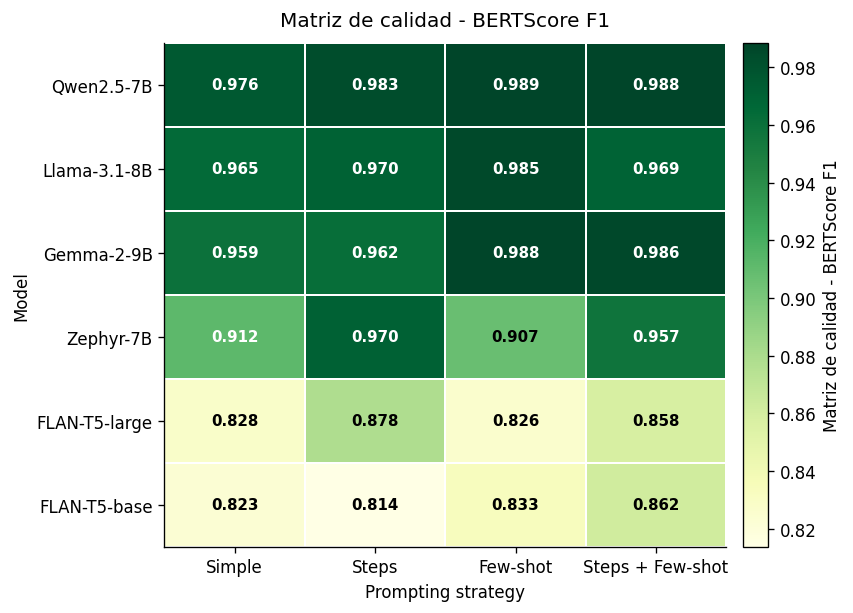

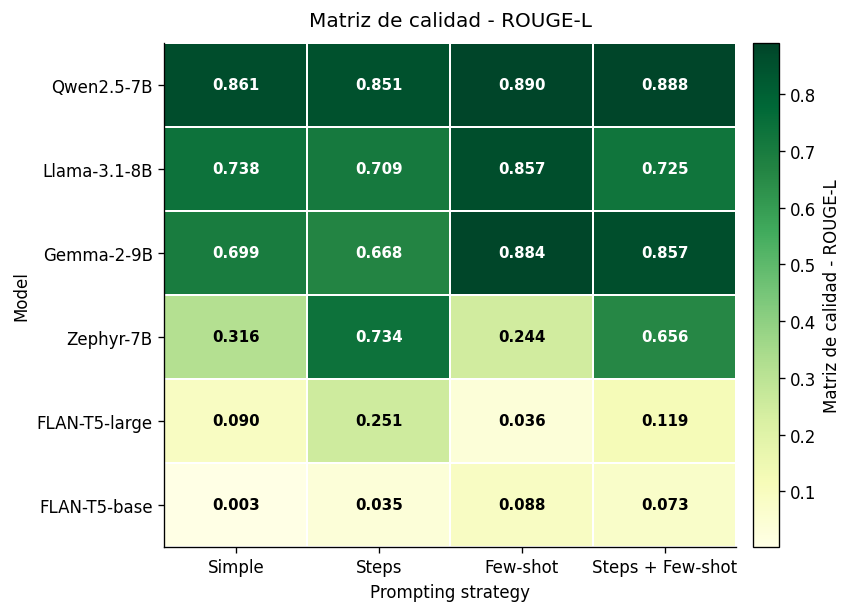

In [71]:
# =========================
# 6) Matriz de calidad
#    - BERTScore F1
#    - ROUGE-L
#    En dos imágenes separadas
# =========================

bert_matrix = make_matrix(master_df, "bertscore_f1", model_order, PROMPT_ORDER)
rougel_matrix = make_matrix(master_df, "rougeL", model_order, PROMPT_ORDER)

def plot_single_heatmap(matrix, title, cmap="YlGn", filename=None):
    fig, ax = plt.subplots(figsize=(7.0, 5.0), constrained_layout=True)

    data = matrix.values.astype(float)
    finite_values = data[np.isfinite(data)]
    vmin = finite_values.min() if finite_values.size else 0.0
    vmax = finite_values.max() if finite_values.size else 1.0

    if math.isclose(vmin, vmax):
        vmin -= 1e-9
        vmax += 1e-9

    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=0)
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_yticklabels(matrix.index)

    ax.set_title(title, pad=10)
    ax.set_xlabel("Prompting strategy")
    ax.set_ylabel("Model")

    ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    norm = Normalize(vmin=vmin, vmax=vmax)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = data[i, j]
            text = "—" if np.isnan(val) else f"{val:.3f}"
            color = "black" if np.isnan(val) else _best_text_color(norm(val))
            ax.text(
                j, i, text,
                ha="center", va="center",
                color=color, fontsize=9, fontweight="bold"
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label(title)

    plt.show()

    if filename:
        maybe_save(fig, filename)

# Figura 1: BERTScore F1
plot_single_heatmap(
    bert_matrix,
    title="Matriz de calidad - BERTScore F1",
    cmap="YlGn",
    filename="01_bertscore_f1_heatmap.png"
)

# Figura 2: ROUGE-L
plot_single_heatmap(
    rougel_matrix,
    title="Matriz de calidad - ROUGE-L",
    cmap="YlGn",
    filename="02_rougel_heatmap.png"
)

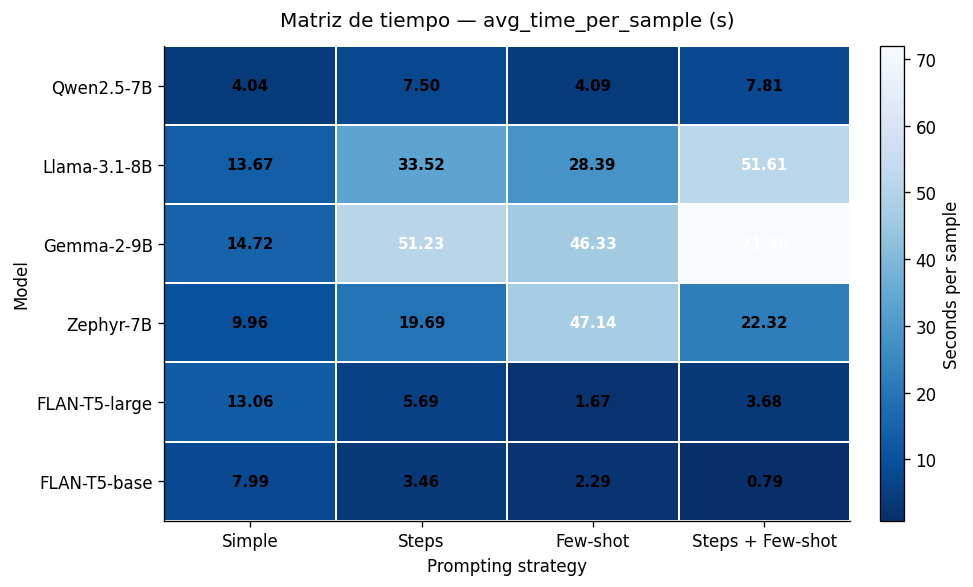

In [72]:
# =========================
# 7) Matriz de tiempo
# =========================
time_matrix = make_matrix(master_df, "avg_time_per_sample", model_order, PROMPT_ORDER)
time_ann = make_annotation_matrix(time_matrix, value_fmt="{:.2f}")

fig, ax = plot_heatmap(
    time_matrix,
    title="Matriz de tiempo — avg_time_per_sample (s)",
    cmap="Blues",
    annotate=time_ann,
    higher_is_better=False,
    figsize=(8.2, 5.0),
    cbar_label="Seconds per sample",
)
plt.show()
maybe_save(fig, "02_time_heatmap.png")

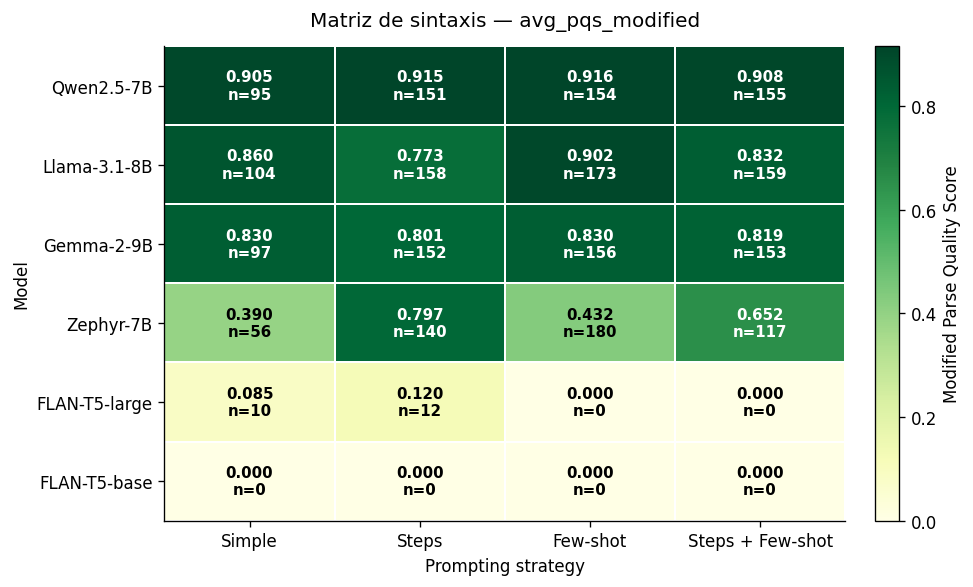

In [73]:

# =========================
# 8) Matriz de sintaxis
#    - avg_pqs_modified
#    - anotación con n = total_modified_files
# =========================
syntax_matrix = make_matrix(master_df, "avg_pqs_modified", model_order, PROMPT_ORDER)
modified_matrix = make_matrix(master_df, "total_modified_files", model_order, PROMPT_ORDER)
syntax_ann = make_annotation_matrix(
    syntax_matrix,
    extra_matrix=modified_matrix,
    value_fmt="{:.3f}",
    extra_prefix="n=",
)

fig, ax = plot_heatmap(
    syntax_matrix,
    title="Matriz de sintaxis — avg_pqs_modified",
    cmap="YlGn",
    annotate=syntax_ann,
    higher_is_better=True,
    figsize=(8.2, 5.0),
    cbar_label="Modified Parse Quality Score",
)
plt.show()
maybe_save(fig, "03_syntax_heatmap.png")


In [74]:

# =========================
# 9) Selección automática de finalistas
#    Solo: Qwen, Llama, Gemma, Zephyr
#    Criterio:
#      1) mayor avg_pqs_modified
#      2) mayor bertscore_f1
#      3) menor avg_time_per_sample
# =========================
finalist_pool = master_df[master_df["model_name"].isin(FINALIST_MODELS)].copy()

best_per_model = (
    finalist_pool
    .sort_values(
        ["model_name", "avg_pqs_modified", "bertscore_f1", "avg_time_per_sample"],
        ascending=[True, False, False, True]
    )
    .groupby("model_name", as_index=False)
    .head(1)
    .copy()
)

best_per_model["finalist_label"] = best_per_model["model_label"] + " | " + best_per_model["prompt_label"].astype(str)
best_per_model = best_per_model.sort_values(
    ["avg_pqs_modified", "bertscore_f1", "avg_time_per_sample"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(
    best_per_model[
        [
            "model_label", "prompt_label", "avg_pqs_modified",
            "bertscore_f1", "rougeL", "avg_time_per_sample",
            "total_modified_files", "total_passed", "total_partially_parsed",
            "total_failed", "total_unknown"
        ]
    ]
)


,model_label,prompt_label,avg_pqs_modified,bertscore_f1,rougeL,avg_time_per_sample,total_modified_files,total_passed,total_partially_parsed,total_failed,total_unknown
0,Qwen2.5-7B,Few-shot,0.915750,0.9885,0.8903,4.0948,154,135,19,0,0
1,Llama-3.1-8B,Few-shot,0.902083,0.9854,0.8566,28.3934,173,146,27,0,0
2,Gemma-2-9B,Few-shot,0.830000,0.9883,0.8845,46.3276,156,113,43,0,0
3,Zephyr-7B,Steps,0.796667,0.9704,0.7343,19.6855,140,102,38,0,0


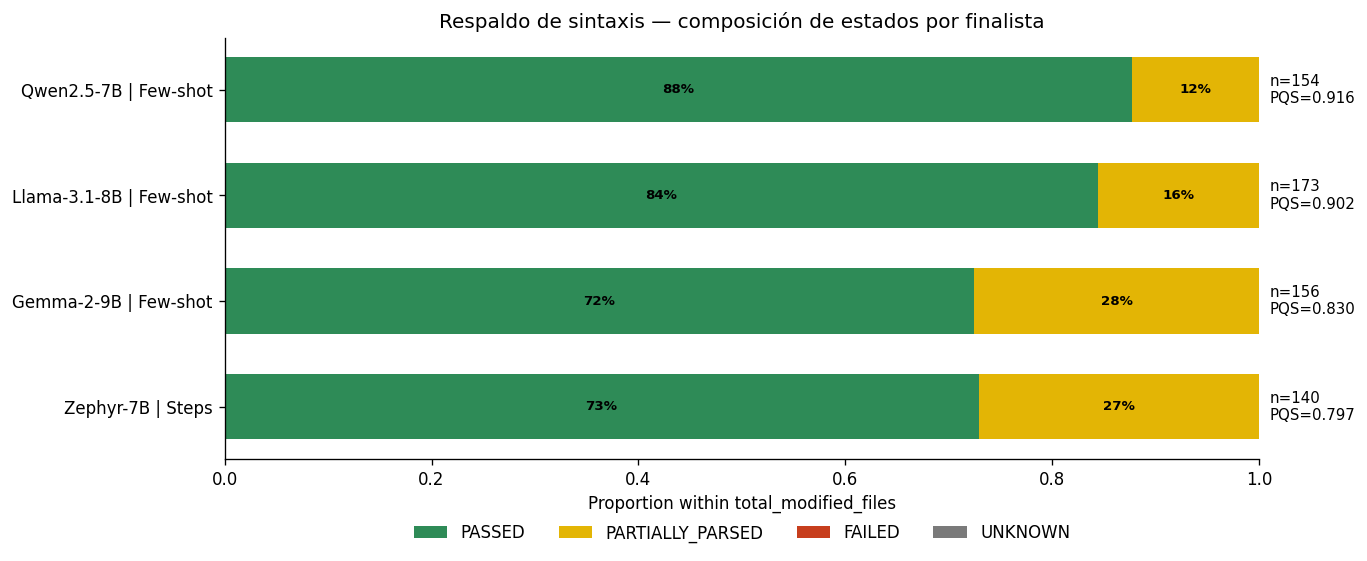

In [75]:

# =========================
# 10) Gráfico de respaldo de sintaxis
#     Barras apiladas al 100% para los 4 finalistas
# =========================
support_df = best_per_model.copy()

for col in ["total_passed", "total_partially_parsed", "total_failed", "total_unknown"]:
    support_df[col] = support_df[col].fillna(0)

support_df["passed_pct"] = np.where(
    support_df["total_modified_files"] > 0,
    support_df["total_passed"] / support_df["total_modified_files"],
    0.0,
)
support_df["partial_pct"] = np.where(
    support_df["total_modified_files"] > 0,
    support_df["total_partially_parsed"] / support_df["total_modified_files"],
    0.0,
)
support_df["failed_pct"] = np.where(
    support_df["total_modified_files"] > 0,
    support_df["total_failed"] / support_df["total_modified_files"],
    0.0,
)
support_df["unknown_pct"] = np.where(
    support_df["total_modified_files"] > 0,
    support_df["total_unknown"] / support_df["total_modified_files"],
    0.0,
)

fig, ax = plt.subplots(figsize=(11.5, 4.8))
y = np.arange(len(support_df))

left = np.zeros(len(support_df))
segments = [
    ("passed_pct", "PASSED", "#2E8B57"),
    ("partial_pct", "PARTIALLY_PARSED", "#E3B505"),
    ("failed_pct", "FAILED", "#C73E1D"),
    ("unknown_pct", "UNKNOWN", "#7A7A7A"),
]

for col, label, color in segments:
    vals = support_df[col].values
    ax.barh(y, vals, left=left, height=0.62, label=label, color=color)
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(support_df["finalist_label"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Proportion within total_modified_files")
ax.set_title("Respaldo de sintaxis — composición de estados por finalista")

for i, row in support_df.iterrows():
    ax.text(
        1.01, i,
        f"n={int(row['total_modified_files'])}\nPQS={row['avg_pqs_modified']:.3f}",
        va="center", ha="left", fontsize=9
    )

cum = np.zeros(len(support_df))
for col, label, color in segments:
    vals = support_df[col].values
    centers = cum + vals / 2
    for i, v in enumerate(vals):
        if v >= 0.10:
            ax.text(centers[i], i, f"{v:.0%}", ha="center", va="center", fontsize=8, color="black", fontweight="bold")
    cum += vals

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()
maybe_save(fig, "04_syntax_support_finalists.png")


In [76]:

# =========================
# 11) Tabla final mínima de decisión
# =========================
decision_table = best_per_model[
    [
        "model_label", "prompt_label", "avg_pqs_modified",
        "bertscore_f1", "rougeL", "avg_time_per_sample", "total_modified_files"
    ]
].copy()

decision_table = decision_table.rename(columns={
    "model_label": "Model",
    "prompt_label": "Prompt",
    "avg_pqs_modified": "avg_pqs_modified",
    "bertscore_f1": "BERTScore F1",
    "rougeL": "ROUGE-L",
    "avg_time_per_sample": "Time/sample (s)",
    "total_modified_files": "Modified files",
})

decision_table.index = np.arange(1, len(decision_table) + 1)
display(decision_table.round({
    "avg_pqs_modified": 3,
    "BERTScore F1": 3,
    "ROUGE-L": 3,
    "Time/sample (s)": 2,
}))


,Model,Prompt,avg_pqs_modified,BERTScore F1,ROUGE-L,Time/sample (s),Modified files
1,Qwen2.5-7B,Few-shot,0.916,0.988,0.890,4.09,154
2,Llama-3.1-8B,Few-shot,0.902,0.985,0.857,28.39,173
3,Gemma-2-9B,Few-shot,0.830,0.988,0.884,46.33,156
4,Zephyr-7B,Steps,0.797,0.970,0.734,19.69,140



## Lectura sugerida para la presentación

- **Primero** muestra la matriz de sintaxis, porque es la métrica operativa principal.
- **Después** muestra la matriz de calidad (BERTScore F1 y ROUGE-L) para verificar fidelidad de contenido.
- **Luego** muestra la matriz de tiempo para exponer el costo.
- **Finalmente** usa el gráfico de respaldo de sintaxis para los 4 finalistas (Qwen, Llama, Gemma y Zephyr), ya con la mejor estrategia de prompting elegida automáticamente por modelo.

Así la decisión queda guiada por:

1. **validez sintáctica**
2. **fidelidad semántica/textual**
3. **eficiencia**
